## Threshold Selection (dari OOF Probabilities — Holdout Belum Disentuh)

Membandingkan 3 metode pemilihan threshold, semuanya dihitung dari OOF
CatBoost v3 (bukan holdout): F1-optimal, Recall-optimal (precision floor
>=30%), dan Cost-based (asumsi FN:FP = 5:1, mengikuti contoh resmi
scikit-learn untuk kasus credit scoring). Holdout baru disentuh setelah
threshold final diputuskan.

# Fungsi Perbandingan Threshold

In [6]:
import pandas as pd
import numpy as np


from sklearn.metrics import precision_recall_curve, confusion_matrix, f1_score

def find_optimal_thresholds(
    y_true: np.ndarray, y_proba: np.ndarray, precision_floor: float = 0.30,
    cost_fn: float = 5, cost_fp: float = 1,
) -> dict:
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
    precision, recall = precision[:-1], recall[:-1]

    f1_scores = np.where((precision + recall) > 0, 2 * precision * recall / (precision + recall + 1e-12), 0)
    f1_threshold = thresholds[np.argmax(f1_scores)]

    valid_mask = precision >= precision_floor
    recall_threshold = thresholds[np.argmax(np.where(valid_mask, recall, -1))] if valid_mask.sum() > 0 else None

    # Perbaikan: pakai thresholds asli (sama seperti f1/recall), bukan linspace kasar
    costs = []
    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        costs.append(cost_fn * fn + cost_fp * fp)
    cost_threshold = thresholds[np.argmin(costs)]
    elkan_threshold = cost_fp / (cost_fp + cost_fn)

    results = {}
    for name, t in [("f1_optimal", f1_threshold), ("recall_optimal", recall_threshold), ("cost_based", cost_threshold)]:
        if t is None:
            continue
        y_pred = (y_proba >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        results[name] = {
            "threshold": float(t),
            "precision": tp / (tp + fp) if (tp + fp) > 0 else 0.0,
            "recall": tp / (tp + fn) if (tp + fn) > 0 else 0.0,
            "f1": f1_score(y_true, y_pred),
            "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
        }
    results["_elkan_theoretical_threshold"] = elkan_threshold
    return results

# Jalankan Perbandingan

In [7]:
import pandas as pd

oof_df = pd.read_csv("../models/catboost_v3/catboost_v3_oof.csv")
oof_true_cb_v3 = oof_df["oof_true"].to_numpy()
oof_proba_cb_v3 = oof_df["oof_proba"].to_numpy()

threshold_results = find_optimal_thresholds(
    oof_true_cb_v3, oof_proba_cb_v3, precision_floor=0.30, cost_fn=5, cost_fp=1,
)

comparison_df = pd.DataFrame({k: v for k, v in threshold_results.items() if k != "_elkan_theoretical_threshold"}).T
print(comparison_df[["threshold", "precision", "recall", "f1", "tn", "fp", "fn", "tp"]])
print(f"\nThreshold teoretis Elkan: {threshold_results['_elkan_theoretical_threshold']:.4f}")

                threshold  precision    recall        f1        tn       fp  \
f1_optimal       0.651070   0.264331  0.449043  0.332774  201328.0  24820.0   
recall_optimal   0.705558   0.300000  0.356495  0.325817  209628.0  16520.0   
cost_based       0.666919   0.274319  0.422860  0.332765  203932.0  22216.0   

                     fn      tp  
f1_optimal      10942.0  8918.0  
recall_optimal  12780.0  7080.0  
cost_based      11462.0  8398.0  

Threshold teoretis Elkan: 0.1667


## Evaluasi Final di Holdout (Sekali, Threshold Sudah Dikunci)

Prediksi holdout HANYA dilakukan sekali di sini, memakai threshold final
0.667 (cost-based, FN:FP=5:1) yang sudah ditentukan dari OOF development
set -- bukan dari holdout ini. Ini laporan performa akhir CatBoost v3.

In [2]:
import sys
import json
from pathlib import Path
import joblib

sys.path.insert(0, str(Path.cwd().parent / "src"))

import config
from modeling.train import (
    set_random_seed, load_featured_dataset, create_or_load_holdout_split, evaluate_predictions,
)

set_random_seed()

df_v3 = load_featured_dataset(path=config.PROCESSED_DATA_DIR / "application_train_featured_v3.csv")

with open(config.PROCESSED_DATA_DIR / "feature_engineering_metadata_v3.json") as f:
    metadata_v3 = json.load(f)

split = create_or_load_holdout_split(df_v3)

holdout_df = df_v3[df_v3[config.ID_COLUMN].isin(split["test_ids"])].reset_index(drop=True)
X_holdout = holdout_df[metadata_v3["tree_features_v3"]]
y_holdout = holdout_df[config.TARGET_COLUMN].to_numpy()

print(f"Ukuran holdout: {len(holdout_df)} baris, jumlah fitur: {X_holdout.shape[1]}, proporsi TARGET=1: {y_holdout.mean():.4f}")

pipeline_final = joblib.load("../models/catboost_v3/catboost_v3_pipeline.joblib")
holdout_proba = pipeline_final.predict_proba(X_holdout)[:, 1]

FINAL_THRESHOLD = 0.6669  # cost-based, FN:FP=5:1, ditentukan dari OOF (bukan dari holdout ini)
holdout_metrics = evaluate_predictions(y_holdout, holdout_proba, threshold=FINAL_THRESHOLD)

print("\n=== Hasil Final di Holdout (CatBoost v3, threshold=0.6669) ===")
for k, v in holdout_metrics.items():
    print(f"{k}: {v}")

print(f"\nPembanding CV (OOF): ROC-AUC 0.7829")
print(f"Holdout             : ROC-AUC {holdout_metrics['roc_auc']:.4f}")

Ukuran holdout: 61503 baris, jumlah fitur: 739, proporsi TARGET=1: 0.0807

=== Hasil Final di Holdout (CatBoost v3, threshold=0.6669) ===
roc_auc: 0.7862127039689942
pr_auc: 0.2838164228247912
log_loss: 0.5311994094288045
accuracy: 0.8621693250735737
precision: 0.27889700327373457
recall: 0.446122860020141
f1: 0.34322460680251027
confusion_matrix: [[50811, 5727], [2750, 2215]]
threshold: 0.6669

Pembanding CV (OOF): ROC-AUC 0.7829
Holdout             : ROC-AUC 0.7862


## Visualisasi Hasil Holdout

ROC curve, Precision-Recall curve, dan confusion matrix dari prediksi
holdout CatBoost v3 (threshold final 0.6669). Disimpan ke reports/figures/
untuk dipakai di README dan laporan portofolio.

# ROC Curve dan PR Curve

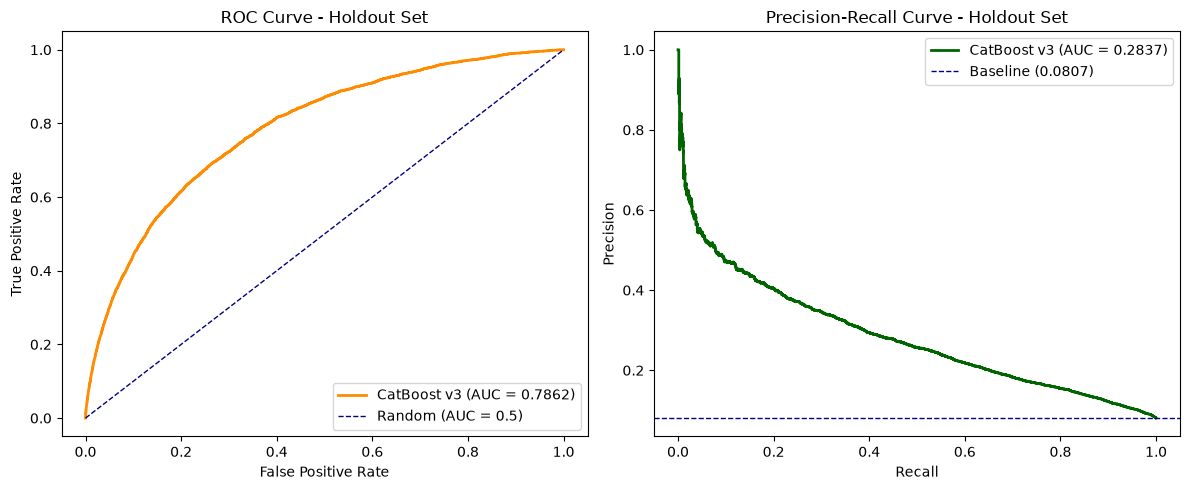

Tersimpan di: ..\reports\figures\holdout_roc_pr_curve.png


In [3]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, auc
from pathlib import Path

FIGURES_DIR = Path("../reports/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

fpr, tpr, _ = roc_curve(y_holdout, holdout_proba)
roc_auc_value = auc(fpr, tpr)

precision_curve, recall_curve, _ = precision_recall_curve(y_holdout, holdout_proba)
pr_auc_value = auc(recall_curve, precision_curve)
baseline_positive_rate = y_holdout.mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(fpr, tpr, color="darkorange", lw=2, label=f"CatBoost v3 (AUC = {roc_auc_value:.4f})")
axes[0].plot([0, 1], [0, 1], color="navy", lw=1, linestyle="--", label="Random (AUC = 0.5)")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve - Holdout Set")
axes[0].legend(loc="lower right")

axes[1].plot(recall_curve, precision_curve, color="darkgreen", lw=2, label=f"CatBoost v3 (AUC = {pr_auc_value:.4f})")
axes[1].axhline(y=baseline_positive_rate, color="navy", lw=1, linestyle="--", label=f"Baseline ({baseline_positive_rate:.4f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve - Holdout Set")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "holdout_roc_pr_curve.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Tersimpan di: {FIGURES_DIR / 'holdout_roc_pr_curve.png'}")

# Confusion Matrix Heatmap

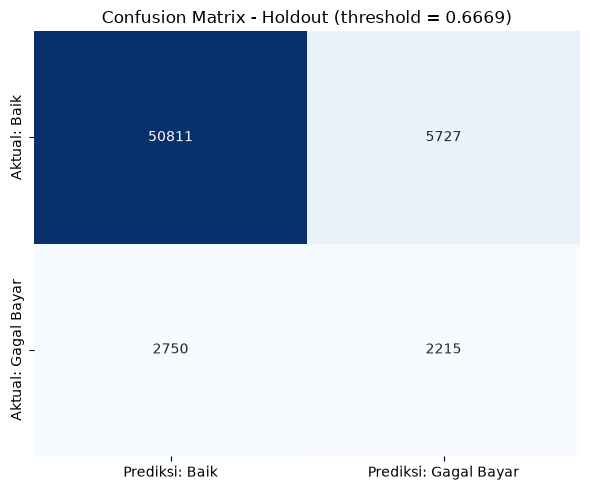

Tersimpan di: ..\reports\figures\holdout_confusion_matrix.png


In [4]:
import seaborn as sns
import numpy as np

cm = np.array(holdout_metrics["confusion_matrix"])

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues", cbar=False,
    xticklabels=["Prediksi: Baik", "Prediksi: Gagal Bayar"],
    yticklabels=["Aktual: Baik", "Aktual: Gagal Bayar"],
    ax=ax,
)
ax.set_title(f"Confusion Matrix - Holdout (threshold = {FINAL_THRESHOLD})")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "holdout_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Tersimpan di: {FIGURES_DIR / 'holdout_confusion_matrix.png'}")

## SHAP - Interpretasi Fitur CatBoost v3

Memakai shap.TreeExplainer (native, exact, cepat untuk model tree-based)
pada 2.000 sampel acak dari holdout -- cukup untuk pola global, jauh lebih
cepat daripada memakai seluruh 61.503 baris. Output: bar plot (importance
global), beeswarm plot (arah dan besar pengaruh), dan waterfall plot untuk
satu kasus individual berisiko tinggi.

In [6]:
import shap
import numpy as np

print(pipeline_final.named_steps.keys())

preprocessor = pipeline_final.named_steps["preprocessor"]
catboost_model = pipeline_final.named_steps["model"]

np.random.seed(42)
sample_idx = np.random.choice(len(X_holdout), size=2000, replace=False)
X_shap_sample = X_holdout.iloc[sample_idx].reset_index(drop=True)

X_shap_transformed = preprocessor.transform(X_shap_sample)

# Ambil nama fitur dari hasil transform kalau masih DataFrame,
# fallback ke kolom mentah kalau preprocessor mengembalikan array/objek lain.
if hasattr(X_shap_transformed, "columns"):
    feature_names = list(X_shap_transformed.columns)
else:
    feature_names = list(X_shap_sample.columns)

print(f"Tipe hasil transform: {type(X_shap_transformed)}")
print(f"Jumlah fitur: {len(feature_names)}")

explainer = shap.TreeExplainer(catboost_model)
shap_values = explainer(X_shap_transformed)
shap_values.feature_names = feature_names

print(f"SHAP values dihitung untuk {shap_values.shape[0]} sampel, {shap_values.shape[1]} fitur.")

dict_keys(['preprocessor', 'model'])
Tipe hasil transform: <class 'pandas.DataFrame'>
Jumlah fitur: 739
SHAP values dihitung untuk 2000 sampel, 739 fitur.


# Bar Plot dan Beeswarm Plot (Global Importance)



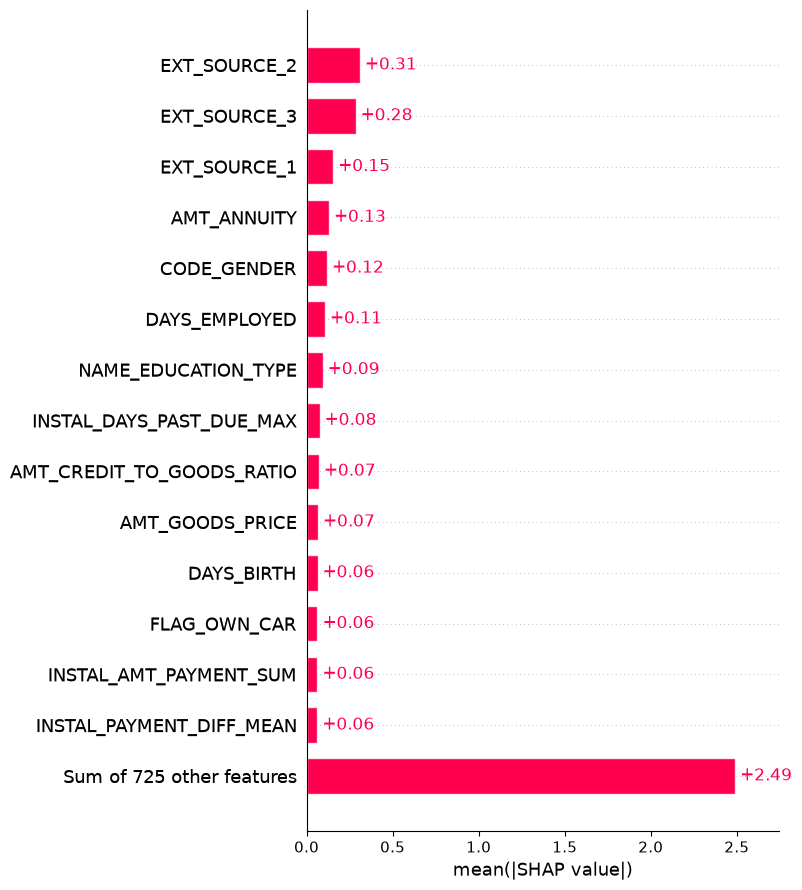

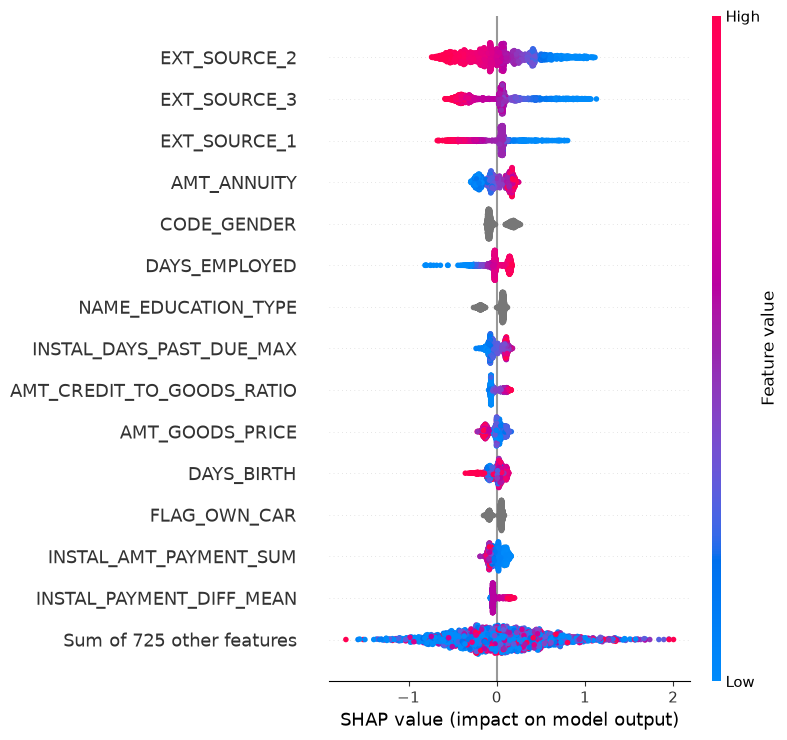

In [7]:
import matplotlib.pyplot as plt

plt.figure()
shap.plots.bar(shap_values, max_display=15, show=False)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "shap_bar_top15.png", dpi=150, bbox_inches="tight")
plt.show()

plt.figure()
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "shap_beeswarm_top15.png", dpi=150, bbox_inches="tight")
plt.show()

# Waterfall Plot untuk Satu Kasus Individual

Sampel dengan prediksi risiko tertinggi: proba = 0.9653


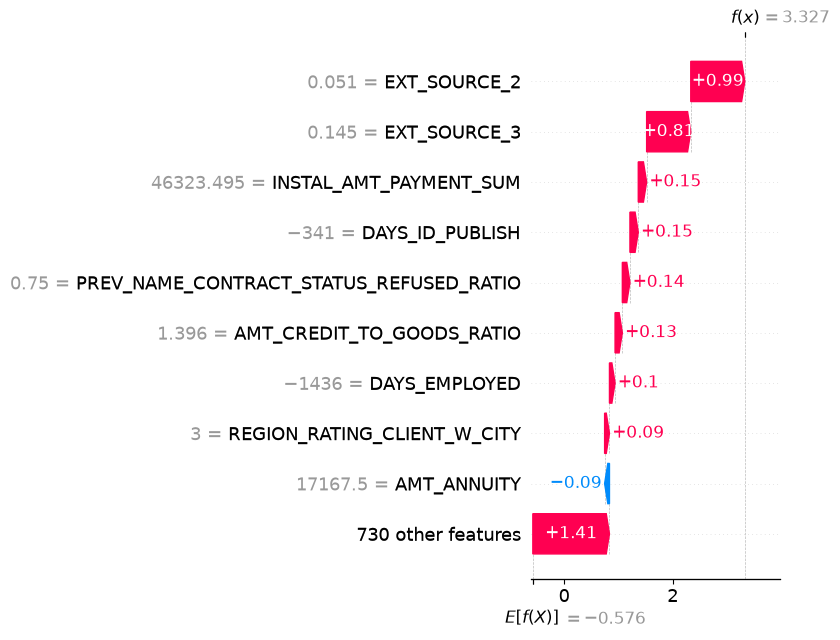

In [8]:
sample_proba = catboost_model.predict_proba(X_shap_transformed)[:, 1]
idx_highest_risk = int(np.argmax(sample_proba))

print(f"Sampel dengan prediksi risiko tertinggi: proba = {sample_proba[idx_highest_risk]:.4f}")

plt.figure()
shap.plots.waterfall(shap_values[idx_highest_risk], show=False)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "shap_waterfall_highest_risk.png", dpi=150, bbox_inches="tight")
plt.show()

## Update Model Summary dengan Hasil Final Holdout

Menambahkan baris khusus status "final_holdout" ke reports/model_summary.csv
supaya jelas dibedakan dari baris-baris hasil CV -- ini angka yang dipakai
untuk laporan resmi ke recruiter, bukan angka eksperimen.

In [10]:
from modeling.train import update_model_summary

update_model_summary({
    "model_name": "catboost_v3_final",
    "run_id": "holdout_eval_001",
    "status": "final_holdout",
    "roc_auc": holdout_metrics["roc_auc"],
    "pr_auc": holdout_metrics["pr_auc"],
    "precision": holdout_metrics["precision"],
    "recall": holdout_metrics["recall"],
    "f1": holdout_metrics["f1"],
    "threshold": FINAL_THRESHOLD,
})

import pandas as pd
summary = pd.read_csv("../reports/model_summary.csv")
print(summary[summary["model_name"] == "catboost_v3_final"])

           model_name            run_id         status feature_path  \
29  catboost_v3_final  holdout_eval_001  final_holdout          NaN   

    n_features_before_encoding  n_features_after_encoding  cv_roc_auc_mean  \
29                         NaN                        NaN              NaN   

    cv_roc_auc_std  cv_pr_auc_mean  cv_pr_auc_std  best_iteration_mean  \
29             NaN             NaN            NaN                  NaN   

    training_time_seconds  random_seed model_path history_path timestamp  
29                    NaN          NaN        NaN          NaN       NaN  
